In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

In [7]:
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/client_wise_sales_2023.csv")

In [8]:
print(df.columns.tolist())

['Customer_Name', 'Sales_Amount', 'Percentage_of_sales', 'Location', 'Type_of_customer']


In [9]:
X = df[['Sales_Amount']]

In [10]:
# Try 3 clusters: High, Medium, Low customers
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(X)

c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [11]:
# Label segments manually (based on cluster centers)
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_indices = cluster_centers.argsort()

segment_labels = {}
segment_labels[sorted_indices[0]] = 'Low Value'
segment_labels[sorted_indices[1]] = 'Medium Value'
segment_labels[sorted_indices[2]] = 'High Value'

df['Segment_Label'] = df['Segment'].map(segment_labels)

In [12]:
df['Segment_Label'] = df['Segment'].map(segment_labels)

print("\nCustomer Segmentation Result:")
print(df[['Customer_Name', 'Sales_Amount', 'Segment_Label']])


Customer Segmentation Result:
                                     Customer_Name  Sales_Amount Segment_Label
0                                     JIndal Group   49980280.51    High Value
1              TANVI Fitness Private Limited (TCS)   33382092.37    High Value
2                      Welspun Corp. Limited (TCS)   26634745.76  Medium Value
3    SURYA ROSHNI LIMITED (3 LPE COATED PIPE UNIT)   18446220.34  Medium Value
4                                      Arcel Group   14755059.32  Medium Value
..                                             ...           ...           ...
485                            Khushbu Gruh Udhyog        800.00     Low Value
486                       SHREE RANGILA ENTERPRIZE        517.80     Low Value
487                              Dipakbhai R Patel        400.00     Low Value
488                 MAHAVIR COLD DRINKS AND SNACKS        344.92     Low Value
489                           BHAGYODAY DAIRY FARM        200.00     Low Value

[490 rows x 3 column

) missing from font(s) DejaVu Sans.pykernel_9628\4257631043.py:7: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.project\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


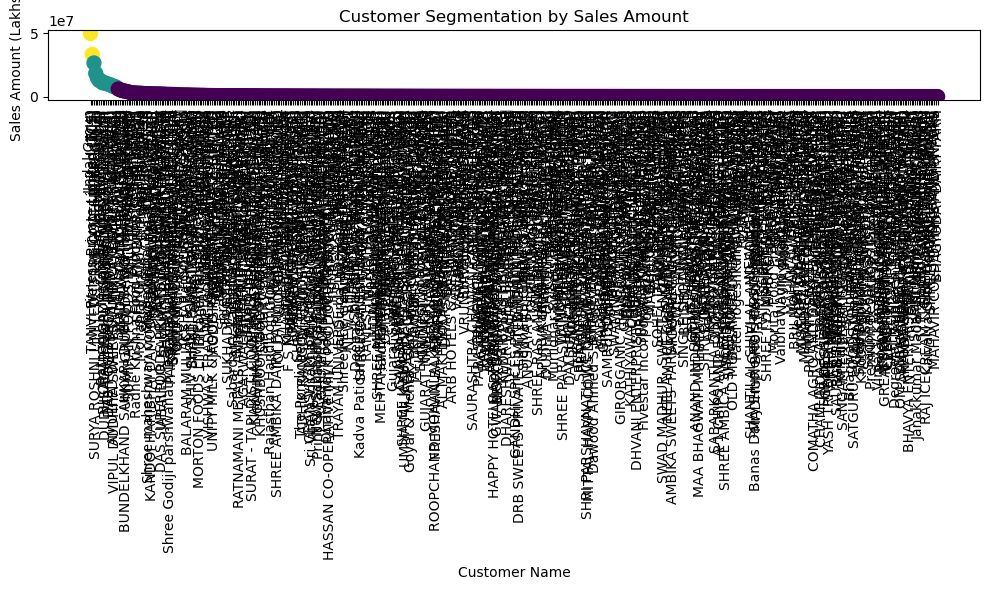

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Customer_Name'], df['Sales_Amount'], c=df['Segment'], cmap='viridis', s=100)
plt.xticks(rotation=90)
plt.title("Customer Segmentation by Sales Amount")
plt.xlabel("Customer Name")
plt.ylabel("Sales Amount (Lakhs)")
plt.tight_layout()
plt.show()

In [14]:
df.to_csv("client_sales_with_segments.csv", index=False)

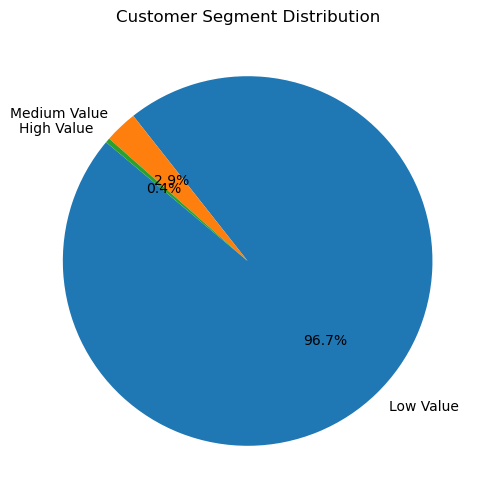

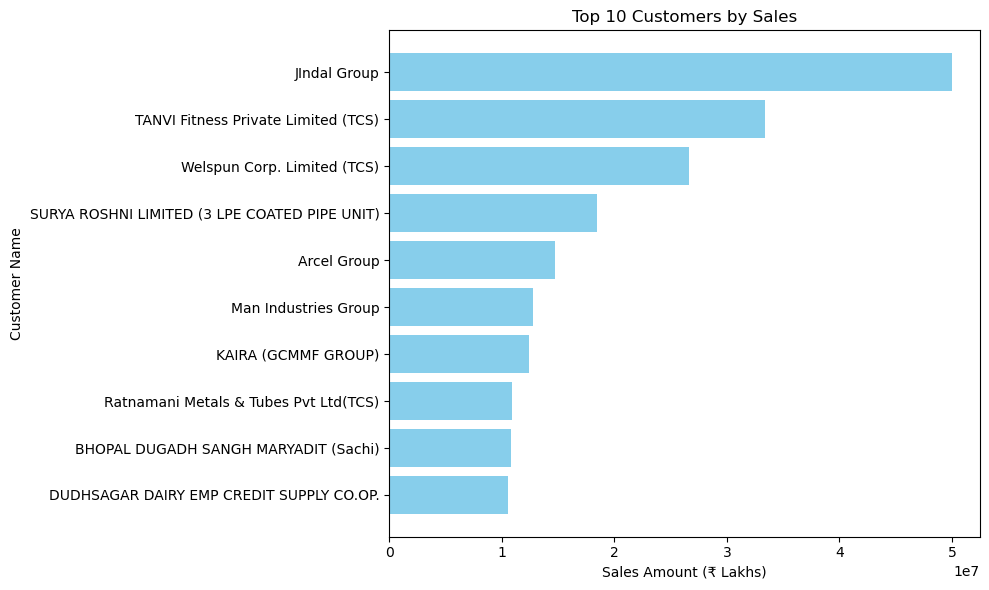

In [15]:
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/client_sales_with_segments.csv")

segment_counts = df['Segment_Label'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Customer Segment Distribution")
plt.show()

top_customers = df.sort_values(by='Sales_Amount', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_customers['Customer_Name'], top_customers['Sales_Amount'], color='skyblue')
plt.xlabel("Sales Amount (₹ Lakhs)")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Sales")
plt.gca().invert_yaxis()  # To show the highest at the top
plt.tight_layout()
plt.show()